https://chatgpt.com/share/69bf9901-9a20-800d-839a-acba71f4b60d

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

## 1.Handling Missing Values

In [2]:
df = sns.load_dataset('titanic')

In [3]:
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    str     
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    str     
 8   class        891 non-null    category
 9   who          891 non-null    str     
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    str     
 13  alive        891 non-null    str     
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), str(5)
memory usage: 80.7 KB


In [5]:
df.isnull().sum()

survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64

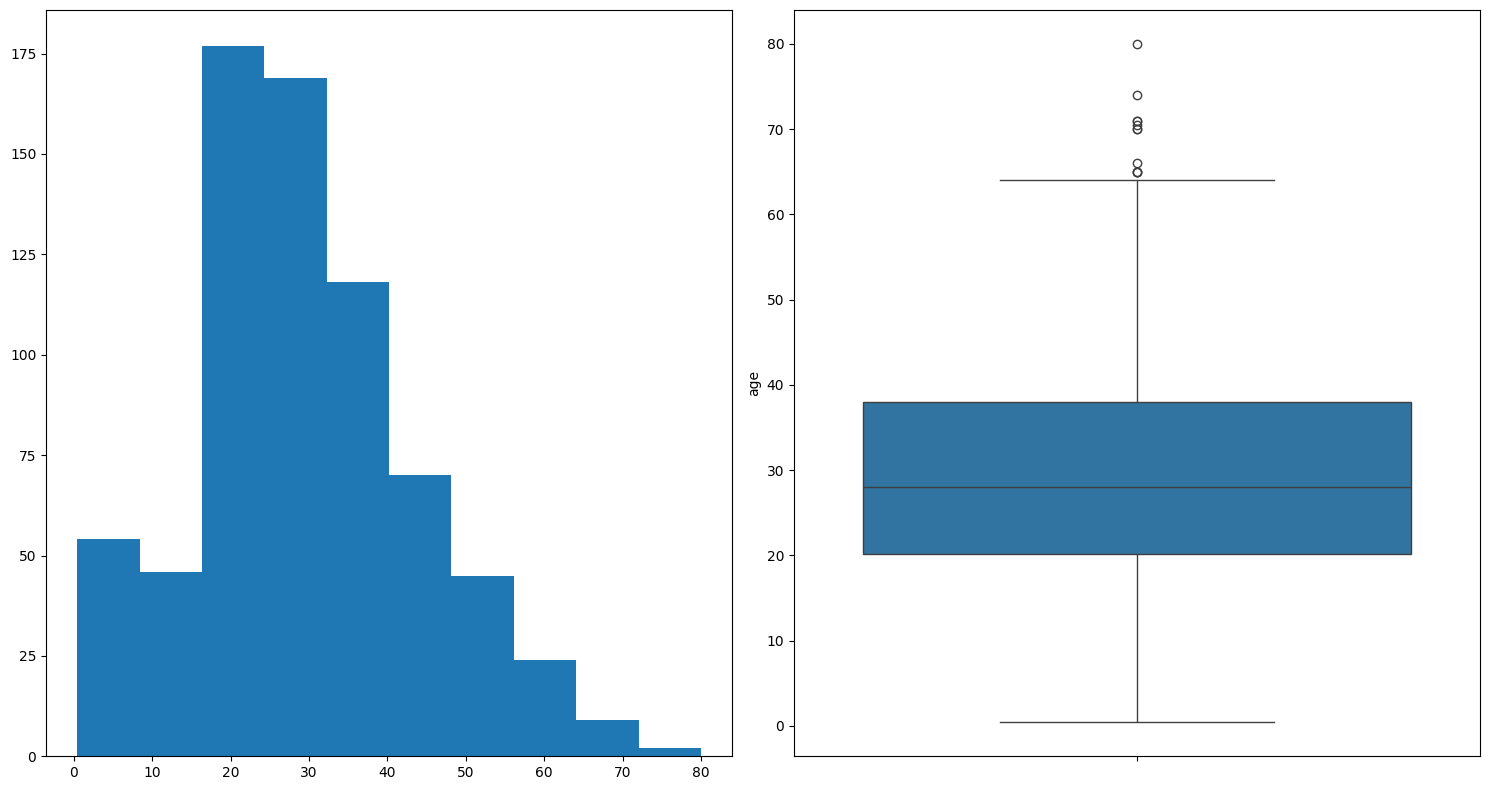

In [6]:
plt.figure(figsize=(15,8))
plt.subplot(1,2,1)
plt.hist(df['age'])
plt.subplot(1,2,2)
sns.boxplot(df['age'])
plt.tight_layout()
plt.show()

In [7]:
df['age'] = df['age'].fillna(df['age'].median())
## OR
from sklearn.impute import SimpleImputer
imputer = SimpleImputer(strategy="mean")
df['age'] = imputer.fit_transform(df['age'].to_frame())

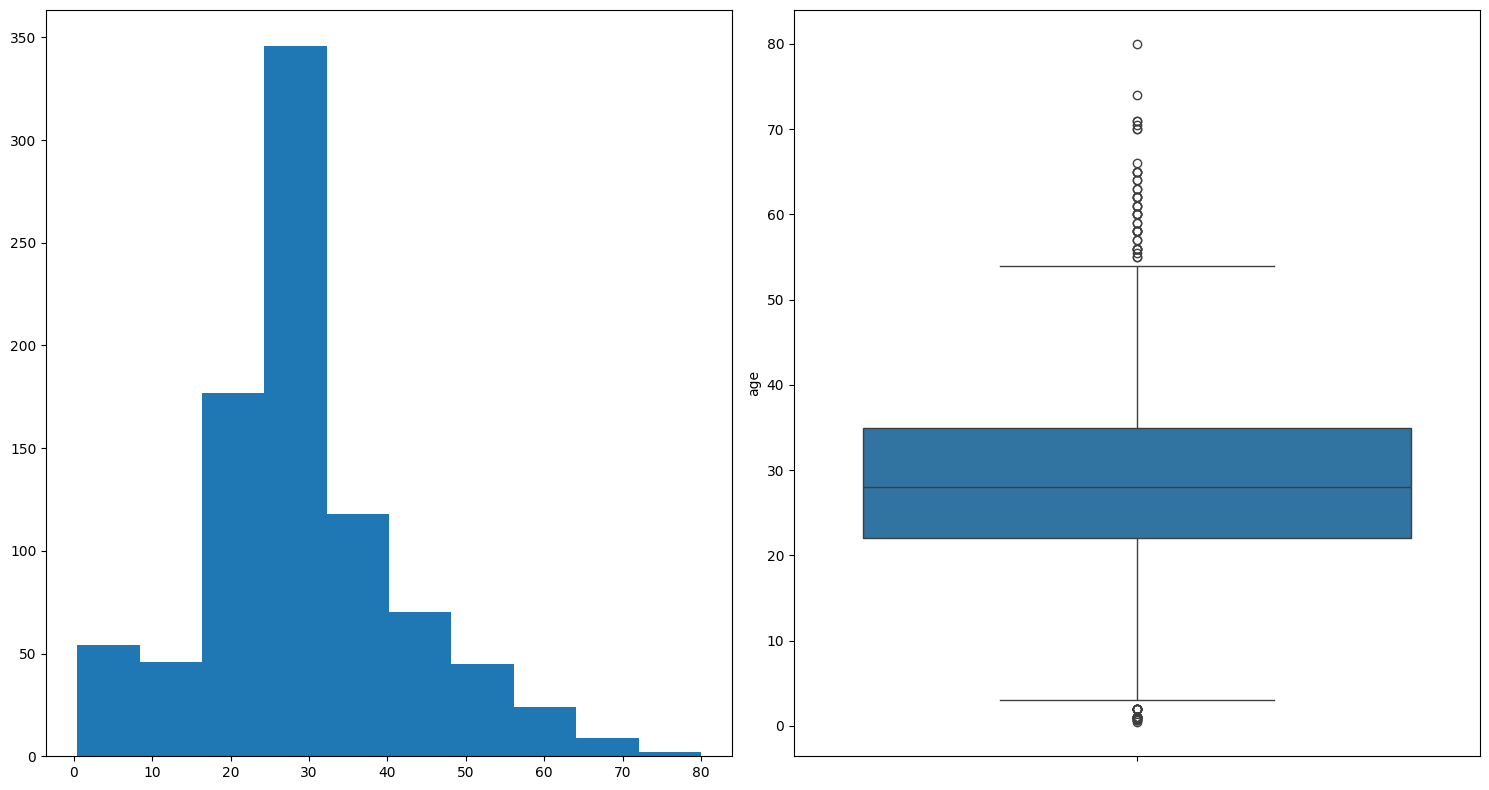

In [8]:
plt.figure(figsize=(15,8))
plt.subplot(1,2,1)
plt.hist(df['age'])
plt.subplot(1,2,2)
sns.boxplot(df['age'])
plt.tight_layout()
plt.show()

In [9]:
df['deck'] = df['deck'].fillna(df['deck'].mode()[0])
df['embark_town'] = df['embark_town'].fillna(df['embark_town'].mode()[0])
df['embarked'] = df['embarked'].fillna(df['embarked'].mode()[0])

In [10]:
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,C,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,C,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,C,Southampton,no,True


### 2. Encoding Categorical Data

In [11]:
from sklearn.preprocessing import LabelEncoder

In [12]:
le = LabelEncoder()

In [13]:
df['sex'] = le.fit_transform(df['sex'])
df['class'] = le.fit_transform(df['class'])
df['adult_male'] = le.fit_transform(df['adult_male'])
df['who'] = le.fit_transform(df['who'])
df['deck'] = le.fit_transform(df['deck'])
df['alive'] = le.fit_transform(df['alive'])
df['alone'] = le.fit_transform(df['alone'])

In [14]:
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,1,22.0,1,0,7.2500,S,2,1,1,2,Southampton,0,0
1,1,1,0,38.0,1,0,71.2833,C,0,2,0,2,Cherbourg,1,0
2,1,3,0,26.0,0,0,7.9250,S,2,2,0,2,Southampton,1,1
3,1,1,0,35.0,1,0,53.1000,S,0,2,0,2,Southampton,1,0
4,0,3,1,35.0,0,0,8.0500,S,2,1,1,2,Southampton,0,1


### 3.One-Hot Encoding using pd

In [15]:
df = pd.get_dummies(df,drop_first=True,dtype=int)

In [16]:
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,class,who,adult_male,deck,alive,alone,embarked_Q,embarked_S,embark_town_Queenstown,embark_town_Southampton
0,0,3,1,22.0,1,0,7.2500,2,1,1,2,0,0,0,1,0,1
1,1,1,0,38.0,1,0,71.2833,0,2,0,2,1,0,0,0,0,0
2,1,3,0,26.0,0,0,7.9250,2,2,0,2,1,1,0,1,0,1
3,1,1,0,35.0,1,0,53.1000,0,2,0,2,1,0,0,1,0,1
4,0,3,1,35.0,0,0,8.0500,2,1,1,2,0,1,0,1,0,1


In [17]:
X = df.drop(columns=['survived'])
y = df['survived']

In [18]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score

In [19]:
X_train,X_test,y_train,y_test = train_test_split(X,y,random_state=42,test_size=0.2)

In [20]:
lr = LinearRegression()

In [21]:
lr.fit(X_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [22]:
y_pred = lr.predict(X_test)

In [23]:
r2_score(y_test,y_pred)

1.0

### 3.One-Hot Encoding using sklearn

In [24]:
from sklearn.preprocessing import OneHotEncoder

In [25]:
ohe = OneHotEncoder(drop='first',sparse_output=False)

In [26]:
data = {'Employee id': [10, 20, 15, 25, 30],
        'Gender': ['M', 'F', 'F', 'M', 'F'],
        'Remarks': ['Good', 'Nice', 'Good', 'Great', 'Nice'],
        }
df1 = pd.DataFrame(data)

In [27]:
one_hot_encoded = ohe.fit_transform(df1)
one_hot_df = pd.DataFrame(one_hot_encoded, columns=ohe.get_feature_names_out())

In [28]:
one_hot_df

,Employee id_15,Employee id_20,Employee id_25,Employee id_30,Gender_M,Remarks_Great,Remarks_Nice
0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
1,0.0,1.0,0.0,0.0,0.0,0.0,1.0
2,1.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,1.0,0.0,1.0,1.0,0.0
4,0.0,0.0,0.0,1.0,0.0,0.0,1.0


### 3. Feature Scaling

In [29]:
data = pd.read_csv('./algo_impliment_real_data_set/Batch_gradient_descent/insurance.csv')

In [30]:
data.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [31]:
## lebel encoding 
data['smoker'] = le.fit_transform(data['smoker'])
data['sex'] = le.fit_transform(data['sex'])

In [32]:
## one hot encoding
data = pd.get_dummies(data,drop_first=True,dtype=int)

In [33]:
data.head()

,age,sex,bmi,children,smoker,charges,region_northwest,region_southeast,region_southwest
0,19,0,27.900,0,1,16884.92400,0,0,1
1,18,1,33.770,1,0,1725.55230,0,1,0
2,28,1,33.000,3,0,4449.46200,0,1,0
3,33,1,22.705,0,0,21984.47061,1,0,0
4,32,1,28.880,0,0,3866.85520,1,0,0


In [34]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   age               1338 non-null   int64  
 1   sex               1338 non-null   int64  
 2   bmi               1338 non-null   float64
 3   children          1338 non-null   int64  
 4   smoker            1338 non-null   int64  
 5   charges           1338 non-null   float64
 6   region_northwest  1338 non-null   int64  
 7   region_southeast  1338 non-null   int64  
 8   region_southwest  1338 non-null   int64  
dtypes: float64(2), int64(7)
memory usage: 94.2 KB


In [35]:
data.isnull().sum()

age                 0
sex                 0
bmi                 0
children            0
smoker              0
charges             0
region_northwest    0
region_southeast    0
region_southwest    0
dtype: int64

In [36]:
data.describe()

,age,sex,bmi,children,smoker,charges,region_northwest,region_southeast,region_southwest
count,1338.000000,1338.000000,1338.000000,1338.000000,1338.000000,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,0.505232,30.663397,1.094918,0.204783,13270.422265,0.242900,0.272048,0.242900
std,14.049960,0.500160,6.098187,1.205493,0.403694,12110.011237,0.428995,0.445181,0.428995
min,18.000000,0.000000,15.960000,0.000000,0.000000,1121.873900,0.000000,0.000000,0.000000
25%,27.000000,0.000000,26.296250,0.000000,0.000000,4740.287150,0.000000,0.000000,0.000000
50%,39.000000,1.000000,30.400000,1.000000,0.000000,9382.033000,0.000000,0.000000,0.000000
75%,51.000000,1.000000,34.693750,2.000000,0.000000,16639.912515,0.000000,1.000000,0.000000
max,64.000000,1.000000,53.130000,5.000000,1.000000,63770.428010,1.000000,1.000000,1.000000


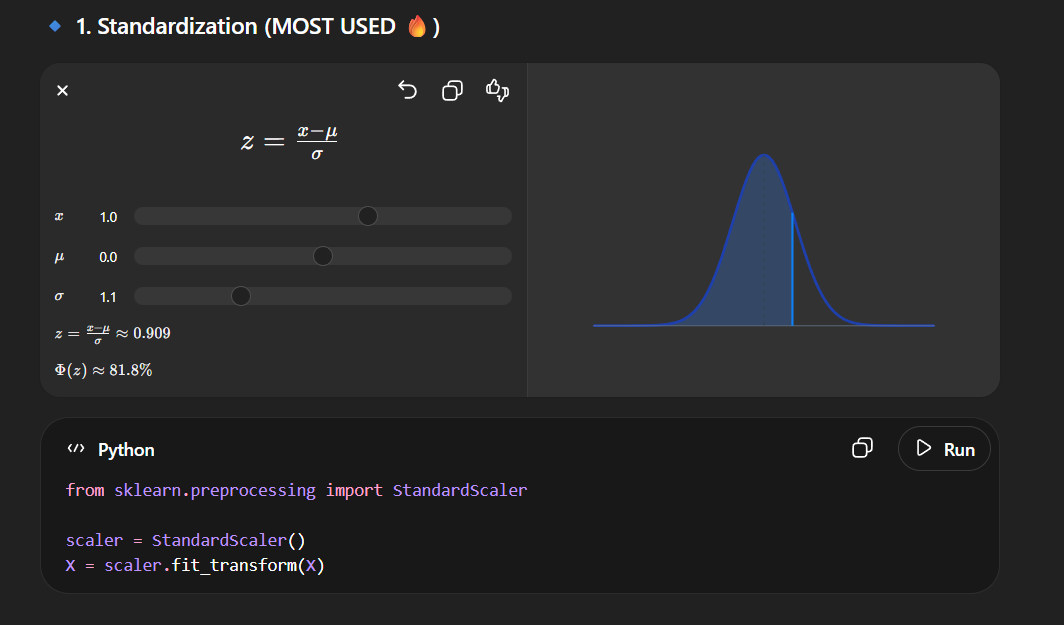

In [37]:
X = data.drop(columns=['charges'])
y = data['charges']

In [43]:
X_train,X_test,y_train,y_test = train_test_split(X,y,random_state=42,test_size=0.2)

In [45]:
model = LinearRegression()
model.fit(X_train,y_train)
y_pred = model.predict(X_test)
r2_score(y_test,y_pred)

0.7835929767120722

| Feature  | StandardScaler | MinMaxScaler  |
| -------- | -------------- | ------------- |
| Range    | (-∞, +∞)       | (0, 1)        |
| Outliers | Handles better | Sensitive ❌   |
| Use case | Most ML models | Deep Learning |


In [38]:
from sklearn.preprocessing import StandardScaler

In [39]:
scaler = StandardScaler()

In [54]:
X_train_scl = scaler.fit_transform(X_train)
X_test_scl = scaler.transform(X_test)

In [57]:
model = LinearRegression()
model.fit(X_train_scl,y_train)
y_pred = model.predict(X_test_scl)

In [58]:
r2_score(y_test,y_pred)

0.7835929767120723

In [63]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [67]:
model = LinearRegression()
model.fit(X_train_scaled,y_train)
y_pred = model.predict(X_test_scaled)
r2_score(y_test,y_pred)

0.7835929767120723

### Feature Selection

<Axes: >

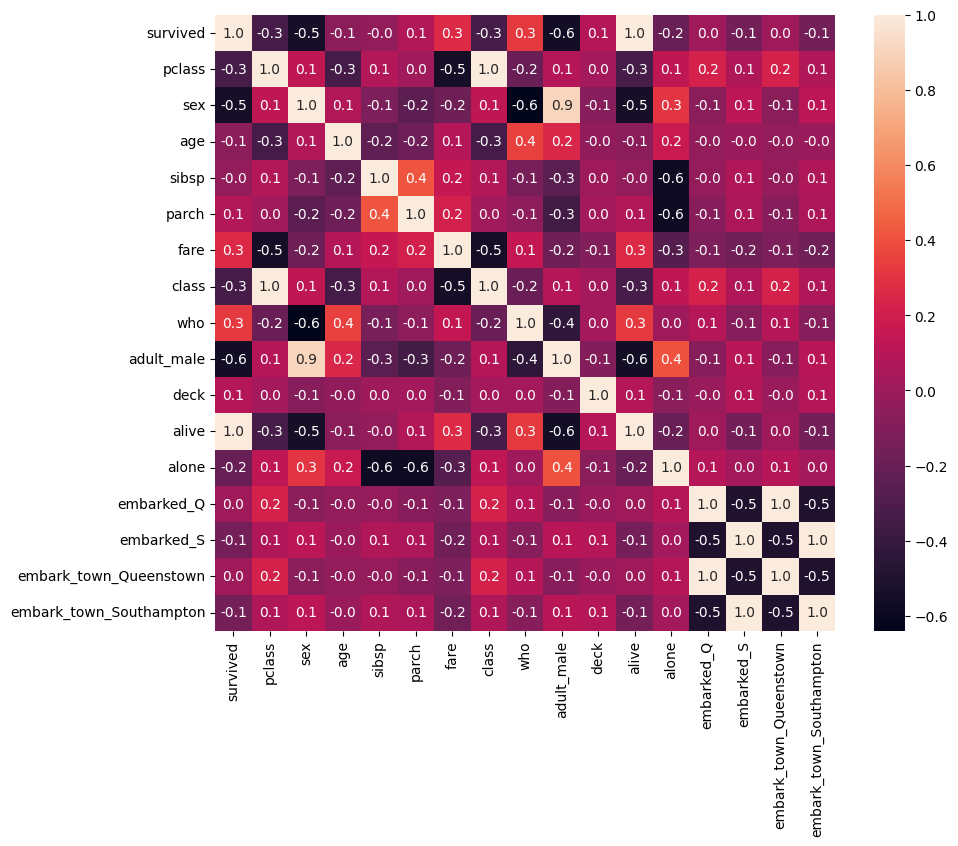

In [73]:
## Correlation
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot=True,fmt=".1f")


In [74]:
### SelectKBest using 

In [88]:
from sklearn.feature_selection import SelectKBest, f_regression

selector = SelectKBest(score_func=f_regression, k=5)
X_train_anova = selector.fit_transform(X_train_scaled, y_train)
X_test_anova = selector.transform(X_test_scaled)

In [89]:
selector.scores_

array([9.20709050e+01, 3.45707513e+00, 4.32657103e+01, 5.54750260e+00,
       1.65995210e+03, 1.21978344e+00, 4.88708675e+00, 1.30946335e+00])

In [90]:
LR = LinearRegression()

In [91]:
LR.fit(X_train_anova,y_train)
y_pred = LR.predict(X_test_anova)
r2_score(y_test,y_pred)

0.7821545605295674